# Runtime Config

In [ ]:
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 13.6 gigabytes of available RAM

Not using a high-RAM runtime


In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Mon Dec 30 10:01:12 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   31C    P8               9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

# Imports and Dependencies

In [ ]:
import numpy as np
import scipy.stats as stats
import pandas as pd
from sklearn import datasets
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score
from sklearn.utils import Bunch
import matplotlib.pyplot as plt
!pip install umap-learn==0.5.3
from sklearn.manifold import TSNE
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn import svm
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
def save_string_to_file(filename, string_to_save):
    try:
        with open(filename, 'x') as file:
            file.write(string_to_save)
        print(f"String successfully saved to {filename}")
    except Exception as e:
        with open(filename, 'w') as file:
            file.write(string_to_save)
        print(f"String successfully saved to {filename}")

In [ ]:
def create_performance_summary(accuracies, validation_accuracies, losses, validation_losses):

  summary = (
      f"Average Accuracy: {np.mean(accuracies):.4f}\n"
      f"Average Validation Accuracy: {np.mean(validation_accuracies):.4f}\n"
      f"Average Loss: {np.mean(losses):.4f}\n"
      f"Average Validation Loss: {np.mean(validation_losses):.4f}"
  )
  return summary

In [ ]:
def review_model_history(name, history):

  modelname = name
  num_epochs = len(history.history['loss'])
  acc_vec = history.history['accuracy']
  val_acc_vec = history.history['val_accuracy']
  loss_vec = history.history['loss']
  val_loss_vec = history.history['val_loss']

  acc_conf_int = confidence_interval(acc_vec, 0.95)
  val_acc_conf_int = confidence_interval(val_acc_vec, 0.95)

  summary = f"""
    Model Summary for {modelname}:
    ------------------------------
    Number of Epochs: {num_epochs}

    Training Accuracy:
    {acc_vec}

    Validation Accuracy:
    {val_acc_vec}

    Training Loss:
    {loss_vec}

    Validation Loss:
    {val_loss_vec}

    Average Training Accuracy:                    Standard Deviation:
    {np.mean(acc_vec)}                              {np.std(acc_vec)}

    Average Validation Accuracy:                  Standard Deviation:
    {np.mean(val_acc_vec)}                        {np.std(val_acc_vec)}

    Training Accuracy Confidence Interval 95%:
    {acc_conf_int}

    Validation Accuracy Confidence Interval 95%:
    {val_acc_conf_int}
    """
  return summary

In [ ]:
def confidence_interval(data, confidence):
  n = len(data)
  mean = np.mean(data)
  sem = stats.sem(data)  # Standard error of the mean
  interval = stats.t.interval(confidence, n - 1, loc=mean, scale=sem)
  return interval

In [ ]:
def visualize_model_performance(model_history, model_name):
  #Calculate important metrics
  best_accuracy = max(model_history.history['accuracy'])
  best_val_accuracy = max(model_history.history['val_accuracy'])

  #Display important metrics
  print('Best accuracy is :' + str(best_accuracy))
  print('Best val accuracy is :' + str(best_val_accuracy))

  # Plot training & validation accuracy values
  plt.figure(figsize=(10, 5))
  plt.subplot(1, 2, 1)
  plt.plot(model_history.history['accuracy'])
  plt.plot(model_history.history['val_accuracy'])
  plt.title('Model accuracy')
  plt.ylabel('Accuracy')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Validation'], loc='upper left')

  # Plot training & validation loss values
  plt.subplot(1, 2, 2)
  plt.plot(model_history.history['loss'])
  plt.plot(model_history.history['val_loss'])
  plt.title('Model loss')
  plt.ylabel('Loss')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Validation'], loc='upper left')
  plt.show()

  plt.savefig(f'{model_name}_performance_plot.png') # Save the plot to a PNG file
  plt.clf()



In [ ]:
pip install galaxy-datasets[tensorflow]

# Import data

HUGE THANKS TO @ mwalmsley, amazing githubpage see url : https://github.com/mwalmsley/galaxy-datasets/commit/efabb1220a3617287b93a8bab3d9033ed56d0a95


In [ ]:
import os

# Create the 'Galaxy' directory if it doesn't exist
if not os.path.exists('Galaxy'):
    os.makedirs('Galaxy')

from galaxy_datasets import gz2  # or gz_hubble, gz_candels, ...

catalog, label_cols = gz2(
    root='Galaxy/gz2',
    train=True,
    download=True
)

In [ ]:
import tensorflow as tf
from galaxy_datasets.tensorflow.datasets import get_image_dataset, add_transforms_to_dataset
from galaxy_datasets.transforms import default_transforms  # same transforms as PyTorch

train_dataset = get_image_dataset(
    image_paths = catalog['file_loc'],
    labels=catalog[label_cols].values,
    requested_img_size=224
)

print(len(train_dataset))

# Get the first element using an iterator and take(1)
element = next(iter(train_dataset.take(1)))
print(element)

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.24 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


167434
(<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
array([[[5.14933392e-02, 5.93364388e-02, 8.35819356e-03],
        [5.67922443e-02, 6.46338761e-02, 1.37319556e-02],
        [5.29347733e-02, 6.07373714e-02, 1.67313814e-02],
        ...,
        [0.00000000e+00, 1.47676896e-02, 6.13963130e-05],
        [2.06728792e-03, 2.19314247e-02, 0.00000000e+00],
        [6.22012187e-03, 2.57629510e-02, 1.97662599e-03]],

       [[6.64154738e-02, 7.42571205e-02, 2.34884638e-02],
        [6.85637370e-02, 7.63637349e-02, 3.18108797e-02],
        [5.68741858e-02, 6.48534670e-02, 2.15118974e-02],
        ...,
        [0.00000000e+00, 1.48247015e-02, 6.13959855e-05],
        [2.06727698e-03, 2.19314303e-02, 0.00000000e+00],
        [6.22008881e-03, 2.57629007e-02, 1.97661528e-03]],

       [[6.19380735e-02, 6.97406605e-02, 2.52441559e-02],
        [6.32638484e-02, 7.12431297e-02, 2.80150827e-02],
        [5.01276404e-02, 5.50294146e-02, 2.07867492e-02],
        ...,
        [0.00000000e+00,

# Data Dictionary

In [ ]:
import pandas as pd

# Initialize an empty string to hold all the information
data_dictionary = ""

# Get descriptive statistics for all label columns
data_dictionary += f"Descriptive statistics for all label columns: {label_cols}\n"
data_dictionary += f"Descriptive statistics for label columns:\n{catalog[label_cols].describe()}\n\n"

target_cols = label_cols

# Loop through each label column to get unique values and value counts
for col in label_cols:

    unique_vals = catalog[col].unique()
    value_counts = catalog[col].value_counts()
    data_dictionary += f"Unique values for {col}: {unique_vals}\n"
    data_dictionary += f"Counts of unique values for {col}: \n{value_counts}\n\n"

# Print the final data dictionary
print(data_dictionary)
save_string_to_file("data_dictionary.txt", data_dictionary)


Descriptive statistics for all label columns: ['smooth-or-featured-gz2_smooth', 'smooth-or-featured-gz2_featured-or-disk', 'smooth-or-featured-gz2_artifact', 'disk-edge-on-gz2_yes', 'disk-edge-on-gz2_no', 'has-spiral-arms-gz2_yes', 'has-spiral-arms-gz2_no', 'bar-gz2_yes', 'bar-gz2_no', 'bulge-size-gz2_dominant', 'bulge-size-gz2_obvious', 'bulge-size-gz2_just-noticeable', 'bulge-size-gz2_no', 'something-odd-gz2_yes', 'something-odd-gz2_no', 'how-rounded-gz2_round', 'how-rounded-gz2_in-between', 'how-rounded-gz2_cigar', 'bulge-shape-gz2_round', 'bulge-shape-gz2_boxy', 'bulge-shape-gz2_no-bulge', 'spiral-winding-gz2_tight', 'spiral-winding-gz2_medium', 'spiral-winding-gz2_loose', 'spiral-arm-count-gz2_1', 'spiral-arm-count-gz2_2', 'spiral-arm-count-gz2_3', 'spiral-arm-count-gz2_4', 'spiral-arm-count-gz2_more-than-4', 'spiral-arm-count-gz2_cant-tell']
Descriptive statistics for label columns:
       smooth-or-featured-gz2_smooth  smooth-or-featured-gz2_featured-or-disk  \
count            

# Print Image in filters

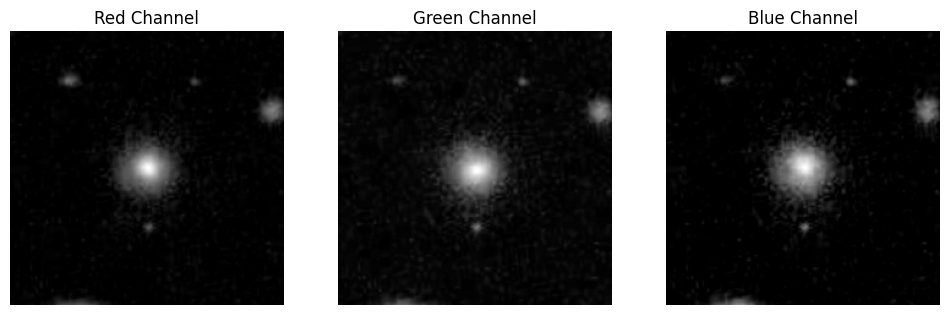

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'element' contains the image data and you want to visualize it
# Access image data (replace with the correct key if needed)
image_data = element[0].numpy()  # Convert to numpy array for easier manipulation

# Assuming the image data has shape (height, width, channels)
height, width, channels = image_data.shape

# Create subplots for each color channel
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

def print_galaxy_pic(image_data):# Plot each color channel
  for i, color in enumerate(['Red', 'Green', 'Blue']):
    axes[i].imshow(image_data[:, :, i], cmap='gray')  # Display each channel as grayscale
    axes[i].set_title(f'{color} Channel')
    axes[i].axis('off')  # Hide axis ticks and labels

  plt.show()
  plt.clf()

print_galaxy_pic(image_data)

# Format Data (Seperate)

Here we will seperate the different filters into different datadrames so it will be easier to work with.

In [ ]:
#Define settings for the data
dataset_size = 1000
sample_size = 1000
picture_size = 224

In [ ]:

# Assuming 'train_dataset' is your TensorFlow dataset
# Create an iterator for the dataset
dataset_iterator = iter(train_dataset)

# Create a list to store the first elements
elements = []

r_images = []
g_images = []
b_images =[]

label_vector = []

# Loop through the iterator and append the elements to the list
for _ in range(dataset_size):
    try:
        element = next(dataset_iterator)
        elements.append(element)

        image_data = element[0].numpy()
        label_data = element[1].numpy()

        label_vector.append(label_data)
        r_images.append(image_data[:, :, 0])
        g_images.append(image_data[:, :, 1])
        b_images.append(image_data[:, :, 2])

    except StopIteration:
        # Handle the case where the dataset has fewer than 1000 elements
        print("Dataset has fewer than 1000 elements.")
        break



In [ ]:
#Verify data set is the same length
print(len(elements))
print(len(r_images))
print(len(g_images))
print(len(b_images))
print(len(label_vector))

#Verfiy shapes of the images
print(elements[0][0].shape)
print(r_images[0].shape)
print(g_images[0].shape)
print(b_images[0].shape)

#Verify label input
print(label_vector[0])


1000
1000
1000
1000
1000
(224, 224, 3)
(224, 224)
(224, 224)
(224, 224)
[37  0  1  0  0  0  0  0  0  0  0  0  0  4 33 32  5  0  0  0  0  0  0  0
  0  0  0  0  0  0]


# Scale Data (Labels)

Here we will scale the data from a scale of 0 - 80 to a scale of 0 - 8 so the output layer will have an easier time predicting the strength of each attribute

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Assuming label_vector is your dataset (2D array or DataFrame)
# Create a MinMaxScaler instance with the desired range [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit and transform the data to scale it between 0 and 1
label_vector_scaled = scaler.fit_transform(label_vector)

# Scale the values to the range [0, 8]
label_vector_scaled_0_8 = label_vector_scaled * 8

# Round the values to get integers
label_vector_scaled_0_8_rounded = np.round(label_vector_scaled_0_8).astype(int)

# Clip the values to ensure they're in the range [0, 8]
label_vector_scaled = np.clip(label_vector_scaled_0_8_rounded, 0, 8)

# Now `label_vector_scaled` contains values between 0 and 8
print(label_vector_scaled)


[[5 0 0 ... 0 0 0]
 [5 0 0 ... 0 0 0]
 [2 3 0 ... 0 0 1]
 ...
 [5 0 0 ... 0 0 0]
 [5 1 0 ... 0 0 0]
 [6 0 1 ... 0 0 0]]


# Reshape Data (Flatten)

Now we will take a 2D array of pixel values and flatten it and clean it to a 1D vector

In [ ]:
# Flatten x_images
r_images_flat = [image.flatten() for image in r_images]
g_images_flat = [image.flatten() for image in g_images]
b_images_flat = [image.flatten() for image in b_images]

# Assuming x_images_flat is a list of 1D numpy arrays, some of which might be empty
r_images_flat_cleaned = [image for image in r_images_flat if image.size > 0]
g_images_flat_cleaned = [image for image in g_images_flat if image.size > 0]
b_images_flat_cleaned = [image for image in b_images_flat if image.size > 0]

# You can now use r_images_flat, which is a list of 1D numpy arrays
print(len(r_images_flat_cleaned))
print(len(r_images_flat_cleaned[0]))
print(len(g_images_flat_cleaned))
print(len(g_images_flat_cleaned[0]))
print(len(b_images_flat_cleaned))
print(len(b_images_flat_cleaned[0]))

1000
50176
1000
50176
1000
50176


# Sample Random Points

In [ ]:
# Create a DataFrame for the images
df_images = pd.DataFrame()

# Add the filters as a new columns, converting lists of arrays to Series
df_images['Red'] = r_images_flat_cleaned
df_images['Green'] = g_images_flat_cleaned
df_images['Blue'] = b_images_flat_cleaned

# Convert label_vector_scaled to a list of lists
label_vector_list = label_vector_scaled.tolist()

# Add the labels as a new column
df_images['target'] = label_vector_list

# Now sample the dataset (30000 random samples)
df_subset = df_images.sample(n=sample_size, random_state=42)

# Split into features (X) and target (y)
X_subset = df_subset.drop(columns=['target'])
y_subset_unformatted = df_subset['target']

# Verify the shapes
print(X_subset.shape)
print(y_subset_unformatted.shape)

print(X_subset.head())
print(y_subset_unformatted[0])


(1000, 3)
(1000,)
                                                   Red  \
521  [0.031918317, 0.037234668, 0.033506494, 0.0208...   
737  [0.025980933, 0.013941646, 0.0055070515, 0.008...   
740  [0.009379138, 0.0024079315, 0.0, 0.0, 0.0, 0.0...   
660  [0.017826438, 0.021769116, 0.019038748, 0.0121...   
411  [0.013480269, 0.0134011125, 0.013417399, 0.013...   

                                                 Green  \
521  [0.016235363, 0.021546718, 0.017846156, 0.0051...   
737  [0.029902507, 0.017863216, 0.009428619, 0.0122...   
740  [0.009379138, 0.0024079315, 0.0, 0.0, 0.0, 0.0...   
660  [0.021748006, 0.025690688, 0.022960315, 0.0161...   
411  [0.0, 0.0, 0.0, 0.0, 0.0030724022, 0.004444746...   

                                                  Blue  
521  [0.0044646333, 0.009901343, 0.0055578416, 0.0,...  
737  [0.00998762, 0.0006117731, 0.0, 0.0, 0.0036920...  
740  [0.009379138, 0.0024079315, 0.0, 0.0, 0.0, 0.0...  
660  [0.0019892848, 0.0057149515, 0.0028378158, 0.0...  

# Reshape Data (Seperate, Label Column)

Here we will seperate the target labels to different aspects so it'd be easier to predict

In [ ]:
import numpy as np
import pandas as pd

# Create an array with 30 columns, filled with zeros initially
y_array = np.zeros((len(y_subset_unformatted), 30))

# Iterate through the rows using y_subset.index to get the correct index values
#y_subset is a pandas Series, so it can be iterated through directly.
for i, values in enumerate(y_subset_unformatted):
    # Check if y_subset[index_val] has at least 30 elements
    if len(values) >= 30:
        y_array[i, :30] = values[:30]
    else:
        # Handle the case where y_subset[index_val] has fewer than 30 elements.
        # You can pad with zeros, use a default value, or raise an error.
        # Here we will pad with zeros
        y_array[i, :len(values)] = values


# Create a DataFrame from the array and assign column names
y_subset = pd.DataFrame(y_array, columns=target_cols[:30]) #only use the number of columns needed.

print(y_subset.head())
print(y_subset.shape)

   smooth-or-featured-gz2_smooth  smooth-or-featured-gz2_featured-or-disk  \
0                            1.0                                      5.0   
1                            0.0                                      4.0   
2                            1.0                                      3.0   
3                            6.0                                      0.0   
4                            5.0                                      2.0   

   smooth-or-featured-gz2_artifact  disk-edge-on-gz2_yes  disk-edge-on-gz2_no  \
0                              0.0                   7.0                  0.0   
1                              0.0                   0.0                  4.0   
2                              0.0                   0.0                  3.0   
3                              0.0                   0.0                  0.0   
4                              0.0                   3.0                  0.0   

   has-spiral-arms-gz2_yes  has-spiral-arms-gz2_no

# t-SNE

Here we will familiarize ourselves with hidden structures within the data using t-SNE

In [ ]:
"""import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

X_subset_array = np.vstack(X_subset['Red'].values)  # Use 'Red', 'Green', or 'Blue' as needed

# Initialize a figure for the matrix of scatter plots
fig, axes = plt.subplots(6, 5, figsize=(20, 20))  # Adjust size for 30 subplots

# Flatten the axes array to easily iterate through them
axes = axes.flatten()

# Perform t-SNE for each column in y_subset and plot the results
for i, col in enumerate(y_subset.columns):
    print(f"Performing t-SNE for column: {col}, {i + 1} / 30")

    # Apply t-SNE on the red channel images
    tsne = TSNE(n_components=2, random_state=42)
    tsne_results = tsne.fit_transform(X_subset_array)

    # Plot the t-SNE results
    ax = axes[i]
    scatter = ax.scatter(tsne_results[:, 0], tsne_results[:, 1], c=y_subset[col], cmap='viridis')

    # Set titles and labels
    ax.set_title(f"t-SNE for {col}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

    # Optional: Add a color bar if desired
    fig.colorbar(scatter, ax=ax)

# Adjust layout
plt.tight_layout()
plt.show()

plt.draw()
plt.savefig('r_image_tsne_plot.png') # Save the plot to a PNG file
plt.clf()"""

'import numpy as np\nimport matplotlib.pyplot as plt\nfrom sklearn.manifold import TSNE\nimport seaborn as sns\n\nX_subset_array = np.vstack(X_subset[\'Red\'].values)  # Use \'Red\', \'Green\', or \'Blue\' as needed\n\n# Initialize a figure for the matrix of scatter plots\nfig, axes = plt.subplots(6, 5, figsize=(20, 20))  # Adjust size for 30 subplots\n\n# Flatten the axes array to easily iterate through them\naxes = axes.flatten()\n\n# Perform t-SNE for each column in y_subset and plot the results\nfor i, col in enumerate(y_subset.columns):\n    print(f"Performing t-SNE for column: {col}, {i + 1} / 30")\n\n    # Apply t-SNE on the red channel images\n    tsne = TSNE(n_components=2, random_state=42)\n    tsne_results = tsne.fit_transform(X_subset_array)\n\n    # Plot the t-SNE results\n    ax = axes[i]\n    scatter = ax.scatter(tsne_results[:, 0], tsne_results[:, 1], c=y_subset[col], cmap=\'viridis\')\n\n    # Set titles and labels\n    ax.set_title(f"t-SNE for {col}")\n    ax.set_xlab

t-SNE analysis is conducted @ n = 2, propelexity = 30, random state = 42.
Conducted on the red filter since light experiences "red-shifting" which would leave the most information even for further objects. Worth to mention set back would be losing some quality in the grantularity of the information perserved.

No noticable structures are present in most of these.

**MOST NOTICABLE**
- how-rounded-gz2_in-between : clusters
- how-rounded-gz2_round : gradient
- smooth-or-featured-gz2_featured-or-disk : clusters
- disk-edge-on-gz2_no : clusters

**Noticable**
- how-rounded-gz2_cigar : gradient
- bulge-shape-gz2_round : clusters
- spiral-arm-count-gz2_cant-tell : clusters



# UMAP

Here we will familiarize ourselves with hidden structures within the data using UMAP

In [ ]:
"""import numpy as np
import matplotlib.pyplot as plt
import umap
import seaborn as sns

X_subset_array = np.vstack(X_subset['Red'].values)  # Use 'Red', 'Green', or 'Blue' as needed

# Initialize a figure for the matrix of scatter plots (6 rows, 5 columns for 30 plots)
fig, axes = plt.subplots(6, 5, figsize=(20, 20))

# Flatten the axes array to easily iterate through
axes = axes.flatten()

# Perform UMAP for each column in y_subset and plot the results
for i, col in enumerate(y_subset.columns):
    print(f"Performing UMAP for column: {col}, {i + 1} / 30")

    # Apply UMAP on the red channel images
    reducer = umap.UMAP(n_components=2, random_state=42)
    umap_results = reducer.fit_transform(X_subset_array)  # Flatten the images

    # Plot the UMAP results in the corresponding subplot
    ax = axes[i]
    scatter = ax.scatter(umap_results[:, 0], umap_results[:, 1], c=y_subset[col], cmap='viridis')

    # Set titles and labels
    ax.set_title(f"UMAP for {col}")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

    # Optional: Add a color bar if desired
    fig.colorbar(scatter, ax=ax)

plt.title('UMAP Visualization of Red Images Subset to Different Target Predictors')
# Adjust layout so that subplots don't overlap
plt.tight_layout()
plt.show()

plt.draw()
plt.savefig('r_image_umap_plot.png') # Save the plot to a PNG file
plt.clf()"""

'import numpy as np\nimport matplotlib.pyplot as plt\nimport umap\nimport seaborn as sns\n\nX_subset_array = np.vstack(X_subset[\'Red\'].values)  # Use \'Red\', \'Green\', or \'Blue\' as needed\n\n# Initialize a figure for the matrix of scatter plots (6 rows, 5 columns for 30 plots)\nfig, axes = plt.subplots(6, 5, figsize=(20, 20))\n\n# Flatten the axes array to easily iterate through\naxes = axes.flatten()\n\n# Perform UMAP for each column in y_subset and plot the results\nfor i, col in enumerate(y_subset.columns):\n    print(f"Performing UMAP for column: {col}, {i + 1} / 30")\n\n    # Apply UMAP on the red channel images\n    reducer = umap.UMAP(n_components=2, random_state=42)\n    umap_results = reducer.fit_transform(X_subset_array)  # Flatten the images\n\n    # Plot the UMAP results in the corresponding subplot\n    ax = axes[i]\n    scatter = ax.scatter(umap_results[:, 0], umap_results[:, 1], c=y_subset[col], cmap=\'viridis\')\n\n    # Set titles and labels\n    ax.set_title(f"U

UMAP analysis is conducted @ n = 2, random state = 42. Conducted on the red filter since light experiences "red-shifting" which would leave the most information even for further objects. Worth to mention set back would be losing some quality in the grantularity of the information perserved.

No noticable structures are present in most of these.

MOST NOTICABLE

how-rounded-gz2_in-between : clusters
how-rounded-gz2_round : gradient
smooth-or-featured-gz2_featured-or-disk : clusters
disk-edge-on-gz2_no : clusters
Noticable

how-rounded-gz2_cigar : gradient
bulge-shape-gz2_round : clusters
spiral-arm-count-gz2_cant-tell : clusters

# Train Simple Model

In [ ]:
from tensorflow.keras.optimizers import Adam

num_initial_epochs = 10

initial_batch_size = 64

inital_add_split = 0.2

optimizer = Adam(learning_rate=0.001)

CNN_optimizer = 'adam'

X_subset_array = np.vstack(X_subset['Red'].values)  # Use 'Red', 'Green', or 'Blue' as needed

y_subset_array = np.vstack(y_subset['smooth-or-featured-gz2_smooth'].values)  # Use different column names as needed

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Define the input shape (1-dimensional vector of length 50176)
input_shape = (len(X_subset_array[0]),)  # 1D input vector with 50,176 elements

# Base model 1:
def create_simplest_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.Dense(896, activation='relu')(inputs)  # Larger dense layer for large input
    x = layers.Dropout(0.5)(x)  # Dropout for regularization
    x = layers.Dense(224, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(56, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(9, activation='softmax')(x)  # Output layer with 9 classes
    model = Model(inputs=inputs, outputs=x)
    return model

simple_model = create_simplest_model(input_shape)

#Set the compiler settings
simple_model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model using the training data for both features and labels
# Added validation_split=0.2 to reserve 20% of training data for validation
simple_model_history = simple_model.fit(X_subset_array, y_subset_array, epochs=num_initial_epochs, batch_size=initial_batch_size, validation_split=inital_add_split)  # Adjust epochs and batch_size as need"""

Epoch 1/10
13/13 [==============================] - 14s 960ms/step - loss: 4.1343 - accuracy: 0.1650 - val_loss: 1.9558 - val_accuracy: 0.3500
Epoch 2/10
13/13 [==============================] - 12s 928ms/step - loss: 2.9773 - accuracy: 0.1437 - val_loss: 1.9780 - val_accuracy: 0.3700
Epoch 3/10
13/13 [==============================] - 12s 938ms/step - loss: 2.4645 - accuracy: 0.1663 - val_loss: 2.0093 - val_accuracy: 0.3700
Epoch 4/10
13/13 [==============================] - 12s 898ms/step - loss: 2.2216 - accuracy: 0.2300 - val_loss: 2.0618 - val_accuracy: 0.3500
Epoch 5/10
13/13 [==============================] - 11s 808ms/step - loss: 2.1943 - accuracy: 0.2125 - val_loss: 2.0514 - val_accuracy: 0.3600
Epoch 6/10
13/13 [==============================] - 12s 906ms/step - loss: 2.0976 - accuracy: 0.2612 - val_loss: 2.0063 - val_accuracy: 0.3550
Epoch 7/10
13/13 [==============================] - 12s 915ms/step - loss: 2.1455 - accuracy: 0.2488 - val_loss: 1.9784 - val_accuracy: 0.3650

String successfully saved to simplest_model_report.text
Best accuracy is :0.29249998927116394
Best val accuracy is :0.3700000047683716


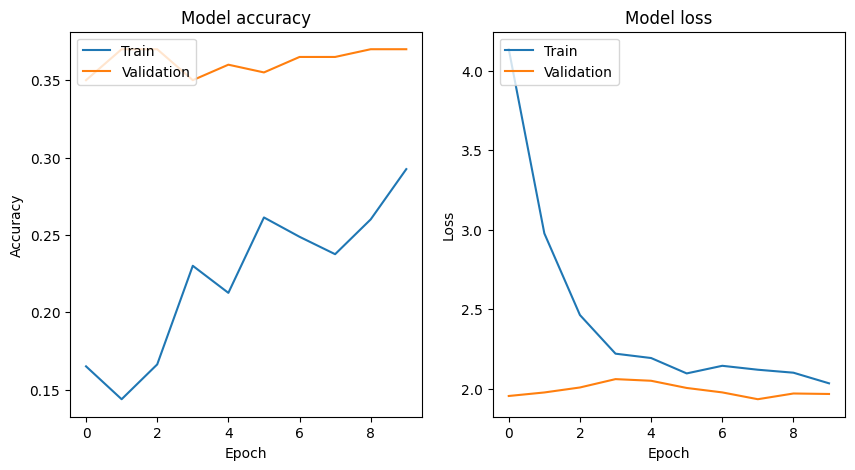

<Figure size 640x480 with 0 Axes>

In [ ]:
# Capture the summary as a string
import io
import sys

# Temporarily capture stdout
old_stdout = sys.stdout
sys.stdout = captured_output = io.StringIO()
simple_model.summary()
sys.stdout = old_stdout

#Collect performance indicators
simple_model_summary = captured_output.getvalue()
simplest_report = review_model_history("simplest_model", simple_model_history)

total_simplest_report = simple_model_summary + "\n" + simplest_report

save_string_to_file('simplest_model_report.text', total_simplest_report)

visualize_model_performance(simple_model_history, "simplest_model")

Model generalizes relatively well. Validation score does way better than training. Low overall accuracy

# Train CNN models

In [ ]:
"""import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the CNN model
CNN_model = keras.Sequential(
    [
        keras.Input(shape=(input_shape[0],)),  # Input layer
        layers.Reshape((input_shape[0], 1)), # Reshape for 1D CNN
        layers.Conv1D(224, kernel_size=3, activation="relu"),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(56, kernel_size=3, activation="relu"),
        layers.MaxPooling1D(pool_size=2),
        layers.Flatten(),
        layers.Dense(9, activation="softmax"), # Output layer with 9 classes (digits 0-8)
    ]
)


# Compile the model
CNN_model.compile(optimizer=CNN_optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

CNN_model_history = CNN_model.fit(X_subset_array, y_subset_array, epochs=num_initial_epochs, batch_size=initial_batch_size, validation_split=inital_add_split)  # Adjust epochs and batch_size as need"""

'import tensorflow as tf\nfrom tensorflow import keras\nfrom tensorflow.keras import layers\n\n# Define the CNN model\nCNN_model = keras.Sequential(\n    [\n        keras.Input(shape=(input_shape[0],)),  # Input layer\n        layers.Reshape((input_shape[0], 1)), # Reshape for 1D CNN\n        layers.Conv1D(224, kernel_size=3, activation="relu"),\n        layers.MaxPooling1D(pool_size=2),\n        layers.Conv1D(56, kernel_size=3, activation="relu"),\n        layers.MaxPooling1D(pool_size=2),\n        layers.Flatten(),\n        layers.Dense(9, activation="softmax"), # Output layer with 9 classes (digits 0-8)\n    ]\n)\n\n\n# Compile the model\nCNN_model.compile(optimizer=CNN_optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])\n\nCNN_model_history = CNN_model.fit(X_subset_array, y_subset_array, epochs=num_initial_epochs, batch_size=initial_batch_size, validation_split=inital_add_split)  # Adjust epochs and batch_size as need'

In [ ]:
"""# Capture the summary as a string
import io
import sys

# Temporarily capture stdout
old_stdout = sys.stdout
sys.stdout = captured_output = io.StringIO()
CNN_model.summary()
sys.stdout = old_stdout

#Collect performance indicators
CNN_model_summary = captured_output.getvalue()
CNN_report = review_model_history("CNN_model", CNN_model_history)

CNN_simplest_report = CNN_model_summary + "\n" + CNN_report

save_string_to_file('CNN_model_report.text', CNN_simplest_report)

visualize_model_performance(CNN_model_history, "CNN_model")"""

'# Capture the summary as a string\nimport io\nimport sys\n\n# Temporarily capture stdout\nold_stdout = sys.stdout\nsys.stdout = captured_output = io.StringIO()\nCNN_model.summary()\nsys.stdout = old_stdout\n\n#Collect performance indicators\nCNN_model_summary = captured_output.getvalue()\nCNN_report = review_model_history("CNN_model", CNN_model_history)\n\nCNN_simplest_report = CNN_model_summary + "\n" + CNN_report\n\nsave_string_to_file(\'CNN_model_report.text\', CNN_simplest_report)\n\nvisualize_model_performance(CNN_model_history, "CNN_model")'

**Very poor generalizing. Seems like the model doesn't grasp the pattern behind the classified**

In [ ]:
"""import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the CNN model
swish_CNN_model = keras.Sequential(
    [
        keras.Input(shape=(input_shape[0],)),  # Input layer
        layers.Reshape((input_shape[0], 1)), # Reshape for 1D CNN
        layers.Conv1D(224, kernel_size=3, activation="swish"),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(56, kernel_size=3, activation="swish"),
        layers.MaxPooling1D(pool_size=2),
        layers.Flatten(),
        layers.Dense(9, activation="softmax"), # Output layer with 9 classes (digits 0-8)
    ]
)


# Compile the model
swish_CNN_model.compile(optimizer=CNN_optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

swish_CNN_model_history = swish_CNN_model.fit(X_subset_array, y_subset_array, epochs=num_initial_epochs, batch_size=initial_batch_size, validation_split=inital_add_split)  # Adjust epochs and batch_size as need"""

'import tensorflow as tf\nfrom tensorflow import keras\nfrom tensorflow.keras import layers\n\n# Define the CNN model\nswish_CNN_model = keras.Sequential(\n    [\n        keras.Input(shape=(input_shape[0],)),  # Input layer\n        layers.Reshape((input_shape[0], 1)), # Reshape for 1D CNN\n        layers.Conv1D(224, kernel_size=3, activation="swish"),\n        layers.MaxPooling1D(pool_size=2),\n        layers.Conv1D(56, kernel_size=3, activation="swish"),\n        layers.MaxPooling1D(pool_size=2),\n        layers.Flatten(),\n        layers.Dense(9, activation="softmax"), # Output layer with 9 classes (digits 0-8)\n    ]\n)\n\n\n# Compile the model\nswish_CNN_model.compile(optimizer=CNN_optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])\n\nswish_CNN_model_history = swish_CNN_model.fit(X_subset_array, y_subset_array, epochs=num_initial_epochs, batch_size=initial_batch_size, validation_split=inital_add_split)  # Adjust epochs and batch_size as need'

# Parameter tuning


In [ ]:
import numpy as np
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from tensorflow.keras import layers, models

# Define a function to create the CNN model
def create_cnn_model(optimizer='adam', kernel_size=3, pool_size=2, activation='relu'):
    model = models.Sequential()
    model.add(layers.Input(shape=(224, 224, 1)))  # Adjust input shape as necessary
    model.add(layers.Conv2D(32, kernel_size=(kernel_size, kernel_size), activation=activation))
    model.add(layers.MaxPooling2D(pool_size=(pool_size, pool_size)))
    model.add(layers.Conv2D(64, kernel_size=(kernel_size, kernel_size), activation=activation))
    model.add(layers.MaxPooling2D(pool_size=(pool_size, pool_size)))
    model.add(layers.Flatten())
    model.add(layers.Dense(9, activation='softmax'))  # 9 classes
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Wrap the Keras model for use with scikit-learn
model = KerasClassifier(build_fn=create_cnn_model, verbose=0)

# Define the hyperparameter grid
param_grid = {
    'optimizer': ['adam', 'rmsprop'],
    'epochs': [10, 20],
    'batch_size': [32, 64],
    'kernel_size': [3, 5],
    'pool_size': [2, 3],
    'activation': ['relu', 'tanh']
}

# Conduct the grid search
grid = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=-1, cv=3)
grid_result = grid.fit(X_train, y_train)

# Summarize the results
print(f"Best: {grid_result.best_score_} using {grid_result.best_params_}")
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']

for mean, std, param in zip(means, stds, params):
    print(f"Mean: {mean}, Std: {std}, Params: {param}")


<ipython-input-30-27a3913c545a>:20: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  model = KerasClassifier(build_fn=create_cnn_model, verbose=0)


NameError: name 'X_train' is not defined

**Even worst generalizing. Seems like the model doesn't grasp the pattern behind the classified data and gets worst over iterations**

In [ ]:
"""# Capture the summary as a string
import io
import sys

# Temporarily capture stdout
old_stdout = sys.stdout
sys.stdout = captured_output = io.StringIO()
swish_CNN_model.summary()
sys.stdout = old_stdout

#Collect performance indicators
swish_CNN_model_summary = captured_output.getvalue()
swish_CNN_report = review_model_history("swish_CNN_model", swish_CNN_model_history)

swish_CNN_simplest_report = swish_CNN_model_summary + "\n" + swish_CNN_report

save_string_to_file('swish_CNN_model_report.text', swish_CNN_simplest_report)

visualize_model_performance(swish_CNN_model_history, "CNN_model")"""

# Train Ensemble Learners

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_subset_array, y_subset, test_size=0.2, random_state=42)

# Reshape your input data for a 2D convolution
image_height = 224  # Adjust if necessary
image_width = 224 # Adjust if necessary
X_train = X_train.reshape(-1, image_height, image_width, 1)  # Reshape for 2D CNN
X_test = X_test.reshape(-1, image_height, image_width, 1)  # Reshape for 2D CNN

# Define a function to create a CNN model with smaller kernel size and 2D convolution
def create_cnn_model(input_shape):
    model = keras.Sequential([
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),  # 2D Convolution with smaller kernel size
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(9, activation="softmax"),  # For 9-class classification
    ])

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Define your ensemble model class
class CNNEnsemble:
    def __init__(self, base_models):
        self.base_models = base_models

    def fit(self, X_train, y_train):
        """Train each base model in the ensemble."""
        # Convert y_train to numpy array and select the target column for 'smooth-or-featured-gz2_smooth'
        y_train_array = y_train['smooth-or-featured-gz2_smooth'].to_numpy()

        for model in self.base_models:
            model.fit(X_train, y_train_array, epochs=3, batch_size=64, verbose=0) # Use y_train_array here

    def predict(self, X_test):
        """Aggregate predictions from each base model."""
        predictions = np.zeros((len(X_test), 9))  # Assuming 9 possible classes

        for model in self.base_models:
            # For each model, get probabilities for all classes
            preds = model.predict(X_test)
            predictions += preds  # Summing probabilities (soft voting)

        # Average the probabilities and get the predicted class
        return np.argmax(predictions / len(self.base_models), axis=1)

In [ ]:
import sys
import io
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model

# Define input_shape here to make it accessible
# input_shape should be (image_height, image_width, channels)
image_height = 224  # Adjust if necessary
image_width = 224  # Adjust if necessary
input_shape = (image_height, image_width, 1)  # Correct input shape for 2D CNN


# Create an ensemble of CNN models
num_models = 3  # Example: create 3 models
base_models = [create_cnn_model(input_shape) for _ in range(num_models)]

# Create the ensemble learner
ensemble = CNNEnsemble(base_models)

# Train the ensemble
ensemble.fit(X_train, y_train)

# Make predictions on the test set
y_pred = ensemble.predict(X_test)

# Evaluate the ensemble
# Convert y_test to numpy array and select the target column for 'smooth-or-featured-gz2_smooth'
y_test_array = y_test['smooth-or-featured-gz2_smooth'].to_numpy()  # Select the desired target column
accuracy = accuracy_score(y_test_array, y_pred)
print(f"Ensemble accuracy: {accuracy}")

In [ ]:
# Additional performance metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(9)]))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualizing the confusion matrix with a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[str(i) for i in range(9)], yticklabels=[str(i) for i in range(9)])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Save ensemble model performance to file
ensemble_report = f"Ensemble model accuracy: {y_pred * 100:.2f}%\n\n"
ensemble_report += "Classification Report:\n" + classification_report(y_test, y_pred, target_names=[str(i) for i in range(9)]) + "\n"
ensemble_report += "Confusion Matrix:\n" + str(conf_matrix) + "\n"

save_string_to_file("ensemble_model_report.txt", ensemble_report)


In [ ]:
# ipython-input-43-3da0a13e5a23
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Split the data into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_subset, y_subset, test_size=0.2, random_state=42)

# Define a function to create a CNN model for each channel
def create_simple_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.Dense(896, activation='relu')(inputs)  # Larger dense layer for large input
    x = layers.Dropout(0.5)(x)  # Dropout for regularization
    x = layers.Dense(224, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(56, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(9, activation='softmax')(x)  # Output layer with 9 classes
    model = Model(inputs=inputs, outputs=x)

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Define the ensemble model class that takes multiple color channels as input
class CNNEnsemble:
    def __init__(self, base_models):
        self.base_models = base_models

    def fit(self, X_train, y_train):
        """Train each base model in the ensemble."""
        # Extract the target column for 'smooth-or-featured-gz2_smooth'
        y_train_array = y_train['smooth-or-featured-gz2_smooth'].to_numpy() #changed here

        for model in self.base_models:
            # Use y_train_array for training, which has the correct shape
            model.fit(X_train, y_train_array, epochs=10, batch_size=128, verbose=0) #changed here

    # Indent the predict function to make it a method of the class
    def predict(self, X_test):
        """Aggregate predictions from each base model."""
        predictions = np.zeros((len(X_test), 9))  # Assuming 9 possible classes

        for model in self.base_models:
            # For each model, get probabilities for all classes
            preds = model.predict(X_test)
            predictions += preds  # Summing probabilities (soft voting)

        # Average the probabilities and get the predicted class
        return np.argmax(predictions / len(self.base_models), axis=1) # Added return statement

In [ ]:
# Prepare the input for each channel separately
X_train_red = np.vstack(X_train['Red'].values)
X_train_green = np.vstack(X_train['Green'].values)
X_train_blue = np.vstack(X_train['Blue'].values)

X_test_red = np.vstack(X_test['Red'].values)
X_test_green = np.vstack(X_test['Green'].values)
X_test_blue = np.vstack(X_test['Blue'].values)

# Create individual CNN models for each channel
# input_shape for create_simple_model should be (number_of_features,)
cnn_model_red = create_simple_model((X_train_red.shape[1],))  # Assuming X_train_red is 2D
cnn_model_green = create_simple_model((X_train_green.shape[1],))
cnn_model_blue = create_simple_model((X_train_blue.shape[1],))

# Create ensemble of CNN models
ensemble_model = CNNEnsemble([cnn_model_red, cnn_model_green, cnn_model_blue])

# Fit the ensemble model
ensemble_model.fit(X_train_red, y_train)

# Get predictions from the ensemble model
ensemble_predictions = ensemble_model.predict(X_test_red)

# Extract the target column for 'smooth-or-featured-gz2_smooth' from y_test
y_test_smooth = y_test['how-rounded-gz2_round'].to_numpy() #changed here

# Evaluate the accuracy of the ensemble using the correct target
ensemble_accuracy = accuracy_score(y_test_smooth, ensemble_predictions)
print(f"Ensemble model accuracy: {ensemble_accuracy * 100:.2f}%")

In [ ]:
# Additional performance metrics
print("\nClassification Report:")
# Select the target column for 'how-rounded-gz2_round' from y_test
y_test_smooth = y_test['how-rounded-gz2_round'].to_numpy()  # Select the desired target column

# Get unique classes in y_test_smooth
unique_classes = np.unique(y_test_smooth)
num_classes = len(unique_classes)

# Use the correct target for classification_report and adjust target_names
print(classification_report(y_test_smooth, ensemble_predictions, target_names=[str(i) for i in unique_classes])) # Modified line

# Confusion matrix
# Use the correct target for confusion_matrix
conf_matrix = confusion_matrix(y_test_smooth, ensemble_predictions)
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualizing the confusion matrix with a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[str(i) for i in unique_classes], yticklabels=[str(i) for i in unique_classes]) # Modified line
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Save ensemble model performance to file
ensemble_reportRGB = f"Ensemble model accuracy: {ensemble_accuracy * 100:.2f}%\n\n"
# Use the correct target for classification_report in the report
ensemble_reportRGB += "Classification Report:\n" + classification_report(y_test_smooth, ensemble_predictions, target_names=[str(i) for i in unique_classes]) + "\n"  # Modified line
ensemble_reportRGB += "Confusion Matrix:\n" + str(conf_matrix) + "\n"

save_string_to_file("ensemble_model_RGB_report.txt", ensemble_reportRGB)